# Parameters

In [256]:
DISEASE = input("Disease: ")
pdf_path = f"../output/{DISEASE}/leiden_report.pdf"
interlayer_transition_prob = 0.05
average_t = [2,4,8,16]
resolution = 1.3
num_neighbors = 400

# Import

In [257]:
# ----------------------------
# Standard library
# ----------------------------
import gc
import json
import os
import pickle
import sys
from collections import Counter, defaultdict
from pathlib import Path
from tempfile import NamedTemporaryFile

# ----------------------------
# Core scientific stack
# ----------------------------
import numpy as np
import pandas as pd

import scipy.sparse as sp
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import linear_sum_assignment
from scipy.sparse.csgraph import connected_components

# ----------------------------
# Visualization
# ----------------------------
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ----------------------------
# Progress / memory profiling
# ----------------------------
from tqdm import tqdm
from pympler import asizeof, muppy

# ----------------------------
# Graph / community detection
# ----------------------------
import igraph as ig
import leidenalg as la
import networkx as nx
import community as community_louvain

# ----------------------------
# PDF utilities
# ----------------------------
from pypdf import PdfReader, PdfWriter

# ----------------------------
# ML / embedding
# ----------------------------
import umap
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors


# Building Multilayer Transition Matrix

In [258]:
# Load all the matrices needed
OUTPUT_DIRECTORY = f"../output/{DISEASE}/"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"
MSIGDB_DIRECTORY = "../../Gen_Hypergraph/output/MSigDB_Full/"

## DGIDB
DGIDB_binary_matrix = sp.load_npz(DGIDB_DIRECTORY + "hypergraph_incidence_matrix_binary.npz")
DGIDB_weighted_matrix = sp.load_npz(DGIDB_DIRECTORY + "hypergraph_incidence_matrix_weighted.npz")
DGIDB_gene_weight_diag_matrix = sp.load_npz(DGIDB_DIRECTORY + "diag_gene_weight_matrix.npz")
DGIDB_diag_node_degree_matrix = sp.load_npz(DGIDB_DIRECTORY + "diag_node_degree_matrix.npz")
DGIDB_inverse_diag_edge_degree_matrix = sp.load_npz(
    DGIDB_DIRECTORY + "inverse_diag_edge_degree_matrix.npz"
    )
DGIDB_inverse_diag_edge_degree_weightless_matrix = sp.load_npz(
    DGIDB_DIRECTORY + "inverse_diag_edge_degree_weightless_matrix.npz"
    )

## MSIGDB
MSIGDB_binary_matrix = sp.load_npz(MSIGDB_DIRECTORY + "hypergraph_incidence_matrix_binary.npz")
MSIGDB_weighted_matrix = sp.load_npz(MSIGDB_DIRECTORY + "hypergraph_incidence_matrix_weighted.npz")
MSIGDB_gene_weight_diag_matrix = sp.load_npz(MSIGDB_DIRECTORY + "gene_weight_diag_matrix.npz")
MSIGDB_diag_node_degree_matrix = sp.load_npz(MSIGDB_DIRECTORY + "diag_node_degree_matrix.npz")
MSIGDB_inverse_diag_edge_degree_matrix = sp.load_npz(
    MSIGDB_DIRECTORY + "inverse_diag_edge_degree_matrix.npz"
    )

In [259]:
# Useful Functions
def csr_equal_tol(A, B, atol=1e-8):
    # First check shapes and sparsity pattern
    if A.shape != B.shape or not np.array_equal(A.indptr, B.indptr) or not np.array_equal(A.indices, B.indices):
        return False
    # Compare numeric values within tolerance
    return np.allclose(A.data, B.data, atol=atol, rtol=0)


# row stochastic check
def row_stochastic_check(A):
    row_sums = np.array(A.sum(axis=1)).ravel()
    print(row_sums)
    ok = np.all(np.isclose(row_sums, 1.0))
    print("Every row sums to 1?", ok)
    return ok

def is_symmetric(W,tol = 1e-12):
    diff = (W - W.T)
    if len(np.abs(diff.data)) == 0:
        print("Matrix is exactly symmetric.")
        return True
    else:
        check = np.all(np.abs(diff.data) < tol)
        print(max(np.abs(diff.data)))
    return check

def degree_array(A, a=1):
    return np.asarray(A.sum(axis=a)).ravel()

def degree_diagonal_matrix(W, a=1):
    d = degree_array(W,a)
    return sp.diags(d, offsets=0, format='csr')

def symmetrically_normalize(W, a=1):
    D = np.asarray(W.sum(axis=a)).ravel()
    D_inv_sqrt = np.zeros_like(D)
    nze = D != 0
    D_inv_sqrt[nze] = 1 / np.sqrt(D[nze])

    W_sym = W.multiply(D_inv_sqrt)              # scale columns
    W_sym = W_sym.multiply(D_inv_sqrt[:, None]) # scale rows    
    return W_sym.tocsr()

def big_objects(n=10, min_mb=1):
    """
    Show the largest objects currently in memory.
    
    Parameters
    ----------
    n : int
        Number of top objects to show.
    min_mb : float
        Minimum size (in MB) to include.
    """
    import sys
    import numpy as np
    import pandas as pd
    import scipy.sparse as sp
    from IPython import get_ipython

    def get_size(obj):
        try:
            if isinstance(obj, np.ndarray):
                return obj.nbytes
            elif isinstance(obj, pd.DataFrame) or isinstance(obj, pd.Series):
                return obj.memory_usage(deep=True).sum()
            elif sp.issparse(obj):
                return (obj.data.nbytes +
                        obj.indptr.nbytes +
                        obj.indices.nbytes)
            else:
                return sys.getsizeof(obj)
        except Exception:
            return 0

    ip = get_ipython()
    if ip is None:
        ns = globals()
    else:
        ns = ip.user_ns

    items = []
    for name, val in ns.items():
        if name.startswith('_'):
            continue  # skip internals
        size = get_size(val)
        if size > min_mb * 1024 ** 2:
            items.append((name, type(val).__name__, size))

    items.sort(key=lambda x: x[2], reverse=True)

    print(f"{'Variable':30s} {'Type':25s} {'Size (MB)':>10s}")
    print("-" * 70)
    for name, t, size in items[:n]:
        print(f"{name:30s} {t:25s} {size / 1024 ** 2:10.2f}")
        
def relative_normality_error(A):
    if sp.issparse(A):
        AH = A.getH()
        AAH = A @ AH
        AHA = AH @ A
        C = AAH - AHA

        num = np.sqrt(np.sum(np.abs(C.data)**2))
        den = max(
            np.sqrt(np.sum(np.abs(AAH.data)**2)),
            np.sqrt(np.sum(np.abs(AHA.data)**2)),
            1e-30
        )
        return num / den
    else:
        AH = A.conj().T
        AAH = A @ AH
        AHA = AH @ A
        return np.linalg.norm(AAH - AHA, 'fro') / max(
            np.linalg.norm(AAH, 'fro'),
            np.linalg.norm(AHA, 'fro'),
            1e-30
        )

In [260]:
# Building Adjacency Matrices

## DGIDB
H,W_v,D_v,D_e_inv, H_bin = DGIDB_weighted_matrix, DGIDB_gene_weight_diag_matrix, DGIDB_diag_node_degree_matrix, DGIDB_inverse_diag_edge_degree_matrix, DGIDB_binary_matrix

d = (D_v @ W_v).diagonal()
d_inv = np.zeros_like(d)
nonzero_mask = d > 0
d_inv[nonzero_mask] = 1.0 / d[nonzero_mask]
D_v_inv = sp.diags(d_inv)

DGIDB_adjacency_matrix = D_v_inv @ H @ D_e_inv @ H.T



In [261]:
# ## MSIGDB
H,W_v,D_v,D_e_inv, H_bin = MSIGDB_weighted_matrix, MSIGDB_gene_weight_diag_matrix, MSIGDB_diag_node_degree_matrix, MSIGDB_inverse_diag_edge_degree_matrix, MSIGDB_binary_matrix

d = (D_v @ W_v).diagonal()
d_inv = np.zeros_like(d)
nonzero_mask = d > 0
d_inv[nonzero_mask] = 1.0 / d[nonzero_mask]
D_v_inv = sp.diags(d_inv)

MSIGDB_adjacency_matrix = D_v_inv @ H @ D_e_inv @ H.T

In [262]:
assert(row_stochastic_check(DGIDB_adjacency_matrix))
assert(row_stochastic_check(MSIGDB_adjacency_matrix))

[1.0000001  0.9999999  1.         1.         1.         1.0000001
 1.         0.9999999  1.         0.99999994 1.         1.
 1.         0.99999994 1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         0.99999994 0.99999994 0.99999994 1.         1.
 0.99999994 1.0000001  0.99999994 1.         0.9999999  1.
 1.         1.         0.99999994 1.         1.         1.
 0.99999994 1.0000001  0.99999994 1.         1.         0.99999994
 1.         1.         1.         0.9999999  0.99999994 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         0.9999999  1.         1.0000001  0.9999998
 0.99999994 1.0000001  1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 0.9999999  1.         1.0000001  1.         1.         1.
 1.         0.99999994 1.         1.         0.99999994 1.
 1.         1.         0.99999994 0.99999994 1.         1.
 1.         1.         1.         

## coupling matrices

In [263]:
## Build interlayer coupling matrices between the two layers

dgidb_to_msigdb_indices = []
# Open the JSON file and load its content into a dictionary
with open(DGIDB_DIRECTORY + "gene_to_index.json", "r") as file:
    dgidb = json.load(file)
with open(MSIGDB_DIRECTORY + "gene_to_index.json", "r") as file:
    msigdb = json.load(file)
DGIDB_index_to_gene = {index: gene for gene, index in dgidb.items()}
MSIGDB_index_to_gene = {index: gene for gene, index in msigdb.items()}

num_genes_msigdb = len(msigdb)
num_genes_dgidb = len(dgidb)

# Intialize the inter-layer matrix with zeros
C12 = np.zeros((num_genes_dgidb,num_genes_msigdb))
C21 = np.zeros((num_genes_msigdb,num_genes_dgidb))
B12_array = np.zeros(num_genes_dgidb)
B21_array = np.zeros(num_genes_msigdb)

i = 0
for gene_dgidb, idx_dgidb in dgidb.items():
    # If the gene exists in both gene-to-index mappings
    if gene_dgidb in msigdb:      
        idx_msigdb = msigdb[gene_dgidb]
        dgidb_to_msigdb_indices.append((idx_dgidb, idx_msigdb))
        i += 1
    else:
        dgidb_to_msigdb_indices.append((idx_dgidb, None))
        print(f"Gene {gene_dgidb} not found in MSIGDB mapping.")
        
# build C21 and C12

for idx_dgidb, idx_msigdb in dgidb_to_msigdb_indices:
    if (idx_msigdb is not None):
        C12[idx_dgidb,:] = MSIGDB_adjacency_matrix.getrow(idx_msigdb).toarray().ravel()
        C21[idx_msigdb,:] = DGIDB_adjacency_matrix.getrow(idx_dgidb).toarray().ravel()
        B12_array[idx_dgidb] = interlayer_transition_prob
        B21_array[idx_msigdb] = interlayer_transition_prob

A12_array = 1 - B12_array
A21_array = 1 - B21_array

B12 = sp.diags(B12_array)
B21 = sp.diags(B21_array)
A12 = sp.diags(A12_array)
A21 = sp.diags(A21_array)
# print stat
print(i/len(dgidb), "of DGIDB genes have a match in MSIGDB")
dgidb_to_msigdb_indices_dict = dict(dgidb_to_msigdb_indices)

with open(OUTPUT_DIRECTORY + "dgidb_to_msigdb_indices_dict.json", 'w') as file:
    json.dump(dgidb_to_msigdb_indices_dict, file, indent=4)
print(f"Mappings saved to {OUTPUT_DIRECTORY}dgidb_to_msigdb_indices_dict.json")   

Gene 360158 not found in MSIGDB mapping.
Gene 11 not found in MSIGDB mapping.
Gene 100302144 not found in MSIGDB mapping.
Gene 100302251 not found in MSIGDB mapping.
Gene 79529 not found in MSIGDB mapping.
Gene 236 not found in MSIGDB mapping.
Gene 652991 not found in MSIGDB mapping.
Gene 267012 not found in MSIGDB mapping.
Gene 693167 not found in MSIGDB mapping.
Gene 927 not found in MSIGDB mapping.
0.9721448467966574 of DGIDB genes have a match in MSIGDB
Mappings saved to ../output/BIPOLAR/dgidb_to_msigdb_indices_dict.json


In [264]:
# build DGIDB_to_real
n1,n2 = num_genes_dgidb,num_genes_msigdb
# dgidb_to_real = []
dgidb_idx = []
gene_to_index_dgidb_new= {}
coupling_matrix = C12
msigdb_idx = np.arange(n1,n1+n2)
num_additional_rows = 0

for didx, midx in dgidb_to_msigdb_indices_dict.items():
    if(midx is None):
        # dgidb_to_real.append(didx)
        dgidb_idx.append(didx) 
        gene_to_index_dgidb_new[DGIDB_index_to_gene[didx]] = num_additional_rows
        num_additional_rows += 1
    # else: 
    #     dgidb_to_real.append(n1 + midx)


    
MSIGDB_gene_to_index_new = {g: i + num_additional_rows for g, i in msigdb.items()}
gene_to_index_distinct = MSIGDB_gene_to_index_new | gene_to_index_dgidb_new

with open(OUTPUT_DIRECTORY + "gene_to_index_distinct.json", 'w') as pathway_file:
    json.dump(gene_to_index_distinct, pathway_file, indent=4)
print(f"Mappings saved to {OUTPUT_DIRECTORY}gene_to_index_distinct.json")    

Mappings saved to ../output/BIPOLAR/gene_to_index_distinct.json


In [265]:
for u, v in dgidb_to_msigdb_indices_dict.items():
    print(1) if v is None else None

1
1
1
1
1
1
1
1
1
1


## construct MTM

In [266]:
A = A12 @ DGIDB_adjacency_matrix
B = B12 @ C12
C = B21 @ C21
D = A21 @ MSIGDB_adjacency_matrix

In [267]:
## Build the multilayer transition matrix
P = sp.bmat([
    [A, B],
    [C, D]
]).tocsr()

num_genes = P.shape[0]
del A, B, C, D
for i in range(3):
    gc.collect()

In [268]:
assert(row_stochastic_check(P))

[1.00000001 0.99999989 0.99999999 ... 1.         1.         1.        ]
Every row sums to 1? True


In [269]:
# P is sparse or dense
A = sp.csr_matrix(P > 0)   # support matrix
n_components, labels = connected_components(A, directed=False)

assert(n_components == 1)

## stationary distribution

In [270]:
def stationary_distribution(W, tol=1e-9, maxit=20000, seed=0):
    # power iteration for left stationary of row-stochastic W
    n = W.shape[0]
    rng = np.random.default_rng(seed)
    pi = rng.random(n) + 1e-12
    pi /= pi.sum()
    for _ in range(maxit):
        pi_next = pi @ W
        if np.linalg.norm(pi_next - pi, 1) < tol:
            break
        pi = pi_next
    return pi / pi.sum()

In [271]:
pi = stationary_distribution(P)

## understand random walk process

In [272]:
# extract the four blocks as A,B,C,D
A = P[0:num_genes_dgidb,0:num_genes_dgidb]
B = P[0:num_genes_dgidb,num_genes_dgidb:num_genes_dgidb+num_genes_msigdb]
C = P[num_genes_dgidb:num_genes_dgidb+num_genes_msigdb,0:num_genes_dgidb]
D = P[num_genes_dgidb:num_genes_dgidb+num_genes_msigdb,num_genes_dgidb:num_genes_dgidb+num_genes_msigdb]

In [273]:
# Find rows of C with nonzero row sum
replicate_idx_msigdb = np.where(C.sum(axis=1) != 0)[0]
replicate_idx_dgidb = np.where(B.sum(axis=1) != 0)[0]

In [274]:
A_sel,B_sel,C_sel,D_sel = A[replicate_idx_dgidb,:], B[replicate_idx_dgidb,:], C[replicate_idx_msigdb,:], D[replicate_idx_msigdb,:]

In [275]:
# average row sum of the four matrices
print("Average row sums (for genes in both layers only):")
print("A (dgidb adjacency matrix): " + str(A_sel.sum(axis=1).mean()))
print("B (interlayer transition matrix): " + str(B_sel.sum(axis=1).mean()))
print("C (interlayer transition matrix): " + str(C_sel.sum(axis=1).mean()))
print("D (msigdb adjacency matrix): " + str(D_sel.sum(axis=1).mean()))

Average row sums (for genes in both layers only):
A (dgidb adjacency matrix): 0.9499999987654126
B (interlayer transition matrix): 0.05000000000000001
C (interlayer transition matrix): 0.04999999993502171
D (msigdb adjacency matrix): 0.9500000000000002


In [276]:
del A, B, C, D, A_sel, B_sel, C_sel, D_sel
for i in range(3):
    gc.collect()

# Aggregation

### Column

In [277]:
num_distinct_row = len(gene_to_index_distinct)
# total number of columns being aggregated from M
total_cols = n1 + n2

rows = np.empty(total_cols, dtype=int)
cols = np.empty(total_cols, dtype=int)
data = np.ones(total_cols, dtype=P.dtype)

# DGIDB part
for k in range(n1):
    rows[k] = k
    cols[k] = gene_to_index_distinct[DGIDB_index_to_gene[k]]

# MSIGDB part
for k in range(n2):
    rows[n1 + k] = n1 + k
    cols[n1 + k] = gene_to_index_distinct[MSIGDB_index_to_gene[k]]

# sparse grouping matrix
A_c = sp.csr_matrix((data, (rows, cols)), shape=(P.shape[1], num_distinct_row))

### Preparing Weights

In [278]:
dgidb_pi_average = pi[0:n1].mean()
msigdb_pi_average = pi[n1:n1+n2].mean()
print("Average stationary probability for DGIDB genes:", dgidb_pi_average)
print("Average stationary probability for MSIGDB genes:", msigdb_pi_average)
print("Ratio of averages (DGIDB/MSIGDB):", dgidb_pi_average / msigdb_pi_average)

Average stationary probability for DGIDB genes: 0.0001971469624115757
Average stationary probability for MSIGDB genes: 4.227397481890016e-05
Ratio of averages (DGIDB/MSIGDB): 4.663553953848546


In [279]:
pi

array([4.31478482e-08, 4.39842508e-04, 9.00511566e-04, ...,
       3.07898741e-10, 3.09949113e-10, 3.09456992e-10])

In [280]:
wD_list,wM_list = [], []
for u, v in dgidb_to_msigdb_indices_dict.items():
    if (v is not None):
        pid = pi[u]
        pim = pi[dgidb_to_msigdb_indices_dict[u] + n1]
        wd = pid / (pid + pim)
        wm = pim / (pid + pim)
        wD_list.append(wd)
        wM_list.append(wm)

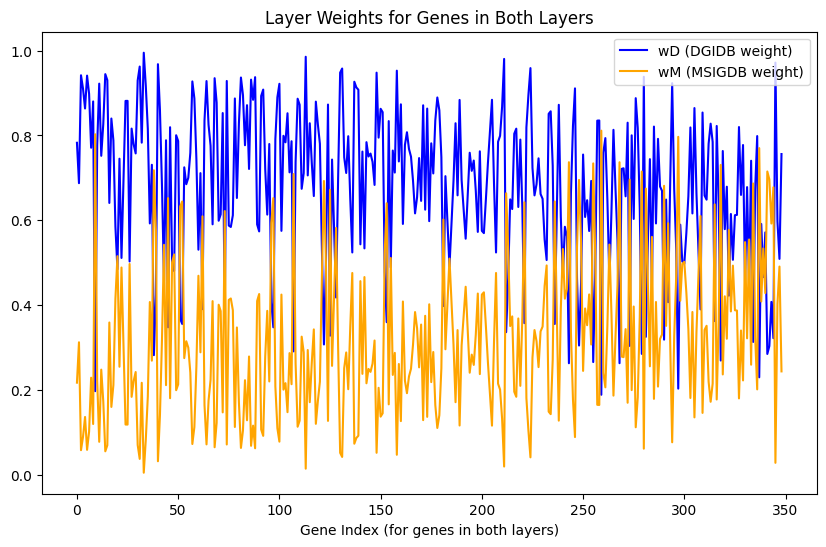

In [281]:
# scatter plot of WD,WM
xaxis = np.arange(len(wD_list))
plt.figure(figsize=(10, 6))
plt.plot(xaxis, wD_list, color = 'blue', label='wD (DGIDB weight)')
plt.plot(xaxis, wM_list, color = 'orange', label='wM (MSIGDB weight)')
plt.xlabel('Gene Index (for genes in both layers)')
plt.legend()
plt.title('Layer Weights for Genes in Both Layers')
plt.savefig(f"../../Graphs/{DISEASE}/pairwise_weights_comparison_for_duplicated_genes.png")

### Row

In [282]:
wD_list2 = []
total_rows = n1 + n2

rows = np.empty(total_rows, dtype=int)
cols = np.empty(total_rows, dtype=int)
data = np.empty(total_rows, dtype=P.dtype)

# DGIDB part
for didx,midx in dgidb_to_msigdb_indices_dict.items():
    rows[didx] = didx
    cols[didx] = gene_to_index_distinct[DGIDB_index_to_gene[didx]]
    if (midx is None):
        data[didx] = 1.0
    else:
        wD = pi[didx] / (pi[didx] + pi[midx + n1])
        wD_list2.append(wD)
        data[didx] = wD

wM_list2_dict = {}
# MSIGDB part
for k in range(n2):
    rows[n1 + k] = n1 + k
    cols[n1 + k] = gene_to_index_distinct[MSIGDB_index_to_gene[k]]
    if (k in dgidb_to_msigdb_indices_dict.values()):
        # find the corresponding dgidb index
        corresponding_dgidb_idx = next(didx for didx, midx in dgidb_to_msigdb_indices_dict.items() if midx == k)
        wM = pi[n1 + k] / (pi[n1 + k] + pi[corresponding_dgidb_idx])
        wM_list2_dict[corresponding_dgidb_idx] = wM
        data[n1 + k] = wM
    else:
        data[n1 + k] = 1.0

# sparse grouping matrix
A_r = (sp.csr_matrix((data, (rows, cols)), shape=(P.shape[0], num_distinct_row))).T.tocsr()

In [283]:
A_r.shape

(21991, 22340)

In [284]:
wM_list2 = [wM_list2_dict[k] for k in sorted(wM_list2_dict)]

In [285]:
# Assert that the weights are computed the same as the graph
assert(wD_list == wD_list2 and wM_list == wM_list2)

# Clustering Methods

In [286]:
def igraph_from_knn_adjacency(A):
    """
    Run Leiden on a symmetric, undirected (weighted) kNN adjacency (SciPy sparse).

    Returns
    -------
    labels : np.ndarray[int]
        Community ID per node (0..k-1)
    quality : float
        Objective value (modularity / RB / CPM depending on 'method')
    """
    # Clean diagonal
    A.setdiag(0.0)
    A.eliminate_zeros()

    # Build igraph from upper triangle (each undirected edge once)
    U = sp.triu(A, k=1, format="coo")
    n = A.shape[0]
    g = ig.Graph(n=n, edges=list(zip(U.row.tolist(), U.col.tolist())), directed=False)
    
    g.es["weight"] = U.data.tolist()
    
    return g

In [287]:
def leiden_from_igraph(
    g,
    *,
    n_iterations=-1,          # -1 => until no improvement
    seed=42,
    resolution=1.0
):
    part_cls = la.RBConfigurationVertexPartition
    # Run Leiden
    part = la.find_partition(
        g,
        part_cls,
        n_iterations=n_iterations,
        seed=seed,
        weights="weight",
        resolution_parameter=resolution
    )

    labels = np.array(part.membership, dtype=np.int32)
    communities = [list(c) for c in part]
    return labels, float(part.quality()), communities

In [288]:
def leiden_from_knn_adjacency(
    A,
    *, 
    n_iterations=-1,          # -1 => until no improvement
    seed=42,):
    g = igraph_from_knn_adjacency(A)
    labels, quality, communities = leiden_from_igraph(g, n_iterations=n_iterations, seed=seed)
    return labels, quality, communities

In [289]:
def community_report_onepage(labels, score, out_pdf="leiden_community_report.pdf", *,
                             extra_text=None, bins="auto", title="Community Sizes", time_steps = "N/A"):
    """
    Create ONE PDF page (top: text summary, bottom: histogram).
    If out_pdf exists: append this page. Else: create it.

    Requires: matplotlib, pypdf  (pip install pypdf)
    """
    # ---- inputs ----
    labels = np.asarray(labels)
    if labels.ndim != 1:
        raise ValueError("labels must be a 1-D array of community ids")

    # ---- stats ----
    sizes = np.bincount(labels.astype(np.int64, copy=False))
    sizes_sorted = np.sort(sizes)
    n, k = sizes.sum(), sizes.size

    lines = [
        "Leiden Partition Summary",
        "========================",
        f"Nodes (n):           {n:,}",
        f"Time steps:          {time_steps}",
        f"Communities (k):     {k:,}",
        f"Size (min):          {int(sizes_sorted[0]) if k else 0:,}",
        f"Size (median):       {float(np.median(sizes_sorted)) if k else 0.0:.3f}",
        f"Size (mean):         {float(sizes_sorted.mean()) if k else 0.0:.6f}",
        f"Size (max):          {int(sizes_sorted[-1]) if k else 0:,}",
        f"Score:               {score}",
        "",
        "Top 10 largest communities (id: size):",
    ]
    for cid in np.argsort(-sizes)[:min(10, k)]:
        lines.append(f"  {int(cid):5d}: {int(sizes[cid]):,}")
    if extra_text:
        lines += ["", "Extra:", *([extra_text] if isinstance(extra_text, str) else list(extra_text))]
    summary_text = "\n".join(lines)

    # ---- draw single-page figure ----
    fig = plt.figure(figsize=(8.5, 11), dpi=150)          # US Letter, higher DPI
    ax_text = fig.add_axes([0.06, 0.55, 0.88, 0.40])      # [left, bottom, width, height]
    ax_text.axis("off")
    ax_text.text(0.0, 1.0, summary_text, va="top", ha="left", fontsize=11, family="monospace")

    ax_hist = fig.add_axes([0.10, 0.08, 0.80, 0.38])
    ax_hist.hist(sizes, bins=bins)
    ax_hist.set_xlabel("Community size")
    ax_hist.set_ylabel("Count of communities")
    ax_hist.set_title(f"Distribution of {title}")

    # ---- write this page to a temp PDF on disk ----
    with NamedTemporaryFile(delete=False, suffix=".pdf") as tmpf:
        tmp_page = Path(tmpf.name)
    with PdfPages(tmp_page) as pdf:
        pdf.savefig(fig)
    plt.close(fig)

    # ---- append/create using PdfReader/PdfWriter (robust across versions) ----
    try:
        from pypdf import PdfReader, PdfWriter
    except Exception as e:
        try: os.remove(tmp_page)
        except: pass
        raise RuntimeError("Please install 'pypdf' (e.g., `pip install pypdf`).") from e

    out_pdf = Path(out_pdf)
    tmp_out = out_pdf.with_suffix(out_pdf.suffix + ".tmp")

    writer = PdfWriter()

    # if existing, copy old pages first
    if out_pdf.exists():
        with open(out_pdf, "rb") as f_exist:
            reader = PdfReader(f_exist)
            for p in reader.pages:
                writer.add_page(p)

    # add the new single page
    with open(tmp_page, "rb") as f_new:
        reader_new = PdfReader(f_new)
        for p in reader_new.pages:
            writer.add_page(p)

    # atomic write
    with open(tmp_out, "wb") as f_out:
        writer.write(f_out)
    os.replace(tmp_out, out_pdf)

    # cleanup
    try: os.remove(tmp_page)
    except: pass

    return out_pdf


# Probe Diffusion Embedding

In [290]:
# Probe generators
def generate_pm1_probes(n, r):
    """±1 probes"""
    S = np.random.choice([-1.0, 1.0], size=(n, r))
    S /= np.linalg.norm(S, axis=0, keepdims=True) + 1e-12
    return S

def generate_random_walk_probes(n, r):
    """Random-walk probes: each column is a probability vector."""  # changed: interpretation now matches an initial distribution
    S = np.random.rand(n, r)  # changed: use nonnegative entries instead of Gaussian entries
    S /= S.sum(axis=0, keepdims=True) + 1e-12  # changed: normalize each column to sum to 1
    return S

def generate_gaussian_probes(n, r, seed=42):
    rng = np.random.default_rng(seed)                          # changed: fixed random seed
    S = rng.standard_normal((n, r))                            # changed: seeded Gaussian samples
    S /= np.linalg.norm(S, axis=0, keepdims=True) + 1e-12
    return S


# ---------------------------
# Diffusion feature builder
# ---------------------------

def build_diffusion_features_for_sources(P, sources, times, normalize=False):
    """
    P: sparse matrix (n x n)
    sources: (n, r)
    times: list of diffusion steps
    """
    times = sorted(times)                                                     # changed: ensure times are processed in increasing order
    Y = sources.copy()                                                        # changed: start from the input probes
    feats = []                                                                # changed: collect propagated probes at each requested time
    cur_t = 0                                                                 # changed: track current diffusion step

    for t in times:
        for _ in range(t - cur_t):
            Y = P.T @ Y                                                       # changed: propagate all probe columns one step
        feats.append(Y.copy())                                                # changed: store features at time t
        cur_t = t                                                             # changed: update current time

    Phi = np.hstack(feats)                                                    # changed: concatenate features from all times

    if normalize:                                                             # changed: optional normalization
        Phi -= Phi.mean(axis=0, keepdims=True)                                # changed: center each feature column
        Phi /= np.std(Phi, axis=0, keepdims=True) + 1e-12                     # changed: scale each feature column

    return Phi                                                                # changed: return feature block for these sources only

## Choosing r based on convergence

In [291]:
# pair-wise distance matrix for each Phi for a subset of genes (for memory efficiency)
from sklearn.metrics import pairwise_distances
def build_embeddings_incrementally_reuse_embedding(
    P, probe_generator, times, r_start=30, r_step=5, r_max=100, normalize=False
):
    """
    Reuse the old embedding by appending only the new feature block.

    Returns
    -------
    embeddings : dict
        embeddings[r] = feature matrix using the first r probes
    """
    n = P.shape[0]                                                            # changed: number of nodes
    embeddings = {}                                                           # changed: store embedding for each r

    sources = probe_generator(n, r_start)                                     # changed: initial probe set
    Phi = build_diffusion_features_for_sources(P, sources, times, normalize=False)  # changed: initial embedding block
    embeddings[r_start] = Phi.copy()                                          # changed: store the first embedding

    current_r = r_start                                                       # changed: track current probe count

    while current_r + r_step <= r_max:
        new_sources = probe_generator(n, r_step)                              # changed: generate only the extra probes
        Phi_new = build_diffusion_features_for_sources(P, new_sources, times, normalize=False)  # changed: compute only the new feature block
        Phi = np.hstack([Phi, Phi_new])                                       # changed: append new features to old embedding
        current_r += r_step                                                   # changed: update probe count

        if normalize:                                                         # changed: optionally normalize the full accumulated embedding
            Phi_store = Phi.copy()                                            # changed: avoid modifying the running unnormalized embedding
            Phi_store -= Phi_store.mean(axis=0, keepdims=True)                # changed: center columns for stored version
            Phi_store /= np.std(Phi_store, axis=0, keepdims=True) + 1e-12     # changed: scale columns for stored version
            embeddings[current_r] = Phi_store                                 # changed: store normalized snapshot
        else:
            embeddings[current_r] = Phi.copy()                                # changed: store unnormalized snapshot

    return embeddings                                                         # changed: return all embeddings


def compute_distance_matrix_for_subset(Phi,subset_size = 3000):
    # sample a subsete of rows for memory efficiency
    num_rows = Phi.shape[0]
    rng = np.random.default_rng(42)
    subset_indices = rng.choice(num_rows, size=subset_size, replace=False)
    Phi_subset = Phi[subset_indices]
    
    D = pairwise_distances(Phi_subset, metric='euclidean', n_jobs=-1)
    return D

# plot relative difference between distance matrices for different number of probes
def relative_difference(D1, D2):
    return np.linalg.norm(D1 - D2, 'fro') / (np.linalg.norm(D1, 'fro') + 1e-12)

def global_rescale(D1, D2, use_upper_triangle=True):
    """
    Find scalar c so that c * D1 best matches D2 in Frobenius norm.
    """
    if use_upper_triangle:
        idx = np.triu_indices_from(D1, k=1)
        x = D1[idx]
        y = D2[idx]
    else:
        x = D1.ravel()
        y = D2.ravel()

    c = np.dot(x, y) / (np.dot(x, x) + 1e-12)
    return c

def rescaled_relative_error(D1, D2, use_upper_triangle=True):
    if use_upper_triangle:
        idx = np.triu_indices_from(D1, k=1)
        x = D1[idx]
        y = D2[idx]
    else:
        x = D1.ravel()
        y = D2.ravel()

    c = np.dot(x, y) / (np.dot(x, x) + 1e-12)
    err = np.linalg.norm(c * x - y) / (np.linalg.norm(y) + 1e-12)
    return err

In [292]:
# embeddings = build_embeddings_incrementally_reuse_embedding(                  
#     P,
#     probe_generator=generate_gaussian_probes,                              
#     times=average_t,
#     r_start=30,
#     r_step=5,
#     r_max=200,
#     normalize=False
# )

# r_values = sorted(embeddings.keys())

In [293]:
# rel_dif_list = []
# for i in r_values[1:]:
#     D_prev, D_curr = compute_distance_matrix_for_subset(embeddings[i]), compute_distance_matrix_for_subset(embeddings[i-5])
#     rel_diff = rescaled_relative_error(D_curr, D_prev)
#     rel_dif_list.append(rel_diff)
#     print(f"Relative difference between embedding with {i} probes and embedding with {i-5} probes: {rel_diff:.6f}")

In [294]:
# # plot rel_dif_list
# plt.figure(figsize=(8, 5))
# plt.plot(r_values[1:], rel_dif_list, marker='o')
# plt.xlabel('Number of Probes')
# plt.ylabel('Relative Difference')
# plt.savefig(f"../../Graphs/{DISEASE}/relative_difference_between_embeddings.png")

## Construct Embedding

In [295]:
num_probes = 150

In [339]:
# # ±1 probes
# pm1_sources = generate_pm1_probes(num_genes, num_probes)
# Phi_pm1 = build_diffusion_features(P, pm1_sources, average_t)

# # Random walk probes
# random_walk_sources = generate_random_walk_probes(num_genes, num_probes)
# Phi_random_walk = build_diffusion_features(P, random_walk_sources, average_t)

# Gaussian probes
sources = generate_pm1_probes(num_genes, num_probes)
Phi = build_diffusion_features_for_sources(P, sources, average_t, normalize=False)

In [341]:
# gaussian_sources_M = generate_gaussian_probes(MSIGDB_adjacency_matrix.shape[0], num_probes)
# Phi_gaussian_M = build_diffusion_features_for_sources(MSIGDB_adjacency_matrix, gaussian_sources_M, average_t, normalize=False)

In [ ]:
# Aggregation to distinct genes
Phi_agg = A_r @ Phi 

In [342]:
# Validation (norms should be slightly smaller for aggregated features, but not orders of magnitude smaller)
print(np.linalg.norm(Phi_agg), np.linalg.norm(Phi))
# print(np.linalg.norm(Phi_random_walk_agg), np.linalg.norm(Phi_random_walk))
# print(np.linalg.norm(Phi_pm1_agg), np.linalg.norm(Phi_pm1))

0.8388566013209292 0.9256323653832444


In [343]:
Phi_agg

array([[ 9.56710633e-08, -1.27494234e-07,  2.26106184e-07, ...,
         1.60129874e-08, -5.91750303e-08,  7.52989683e-08],
       [ 2.29323033e-07,  1.26793694e-07, -1.51660564e-07, ...,
         4.11964767e-08, -1.50489860e-07,  1.92551146e-07],
       [ 9.88768077e-08,  4.80015323e-08, -1.29638150e-07, ...,
         3.44552621e-08, -1.22013772e-07,  1.51195301e-07],
       ...,
       [ 2.48851704e-09, -9.74174170e-10,  3.30458018e-09, ...,
        -3.15533759e-10,  7.00972383e-12,  3.16557319e-10],
       [-3.71423074e-10, -5.49053640e-11, -1.51973127e-09, ...,
        -3.13706107e-10,  2.98437450e-12,  3.20541753e-10],
       [ 6.39677862e-10,  9.83590753e-10, -5.62186006e-10, ...,
        -3.11980025e-10,  1.78458620e-12,  3.21086455e-10]])

In [344]:
Phi_agg.mean()

-3.5610186130267497e-06

In [345]:
np.median(Phi_agg)

-1.2640511007913981e-11

In [346]:
def build_knn_from_phi(phi, k, sym_method="average", metric="euclidean"):
    """
    phi: (n, d) diffusion embedding, one row per node
    k: number of neighbors per node (excluding self)
    sym_method: "average", "union", or "none"
    metric: distance metric for nearest neighbors
    """
    n = phi.shape[0]                                                     # number of nodes

    nbrs = NearestNeighbors(n_neighbors=k+1, metric=metric)              # +1 because self is included
    nbrs.fit(phi)                                                        # index all node embeddings
    distances, indices = nbrs.kneighbors(phi)                            # nearest neighbors for each node

    distances = distances[:, 1:]                                         # remove self-distance
    indices = indices[:, 1:]                                             # remove self-index

    sigma = np.median(distances[:, -1])
    
    rows = np.repeat(np.arange(n), k)                                    # source node for each edge
    cols = indices.ravel()                                               # neighbor node indices
    vals = np.exp(-(distances.ravel() ** 2) / (2 * sigma**2))                           # optional similarity weight from distance

    adj_mat = sp.csr_matrix((vals, (rows, cols)), shape=(n, n))          # directed weighted kNN graph

    if sym_method == "average":
        adj_mat = ((adj_mat + adj_mat.T) * 0.5).tocsr()                  # symmetrize by averaging
    elif sym_method == "union":
        adj_mat = adj_mat.maximum(adj_mat.T)                             # symmetrize by taking larger weight
    elif sym_method == "none":
        pass                                                             # keep directed graph
    else:
        raise ValueError("sym_method must be 'average', 'union', or 'none'")
    
    coo = adj_mat.tocoo()                                                 # changed: convert sparse matrix to COO for igraph
    edges = list(zip(coo.row.tolist(), coo.col.tolist()))                 # changed: igraph wants an edge list
    G = ig.Graph(n=n, edges=edges, directed=(sym_method == "none"))       # changed: output igraph instead of NetworkX
    G.es["weight"] = coo.data.tolist()   
    # build nxgraph for later use

    return adj_mat, G, distances, indices, sigma

# Accuracy Test

In [347]:
# def apply_exact_power_left(x, t):
#     y = x.copy().astype(np.complex128) 
#     for _ in range(t):
#         y = y @ P
#     return y

# def Pt_ith_row_avg(T, i):
#     x = np.zeros(P.shape[0], dtype=np.complex128)
#     x[i] = 1.0
    
#     y_avg = np.zeros_like(x)
#     for t in T:
#         y = apply_exact_power_left(x, t)                       # exact action P^t x
#         y_avg += y
#     y_avg /= len(T)
#     return y_avg

# def distance_estimation_error(num_test):
#     rng = np.random.default_rng(seed = 42)
#     n = P.shape[0]

#     abs_errs = []
#     rel_errs = []
#     list_approx = []
#     list_exact = []

#     for _ in range(num_test):
#         i, j = rng.integers(0, n, size=2)
#         y_i = Pt_ith_row_avg(average_t, i)
#         y_j = Pt_ith_row_avg(average_t, j)

#         d_exact = np.linalg.norm(y_i - y_j)
        
#         # For the approximate distance, we can use the diffusion features
#         # and compute the distance in that space. This is a proxy for the
#         # actual distance estimation error of the truncated method.
#         # In practice, you would compare against the truncated approximation.
#         d_approx = np.linalg.norm(Phi_gaussian[i] - Phi_gaussian[j])
        
#         list_approx.append(d_approx)
#         list_exact.append(d_exact)

#         abs_err = abs(d_exact - d_approx)
#         rel_err = abs_err / (d_exact + 1e-12)

#         abs_errs.append(abs_err)
#         rel_errs.append(rel_err)

#     return abs_errs, rel_errs, list_approx, list_exact
    

In [348]:
# abs_errs, rel_errs, rank_approx, rank_exact = distance_estimation_error(num_test=5)

# Final Average DDBC

In [349]:
# Final Average Clustering
label_list = []
score_list = []
graph_list = []
communities_list = []

In [350]:
kNN_adjacency_matrix, kNN_graph, distances, indices, sigma = build_knn_from_phi(Phi_agg,
                                                                                k=num_neighbors, 
                                                                                sym_method="average", 
                                                                                metric="euclidean")



In [351]:
# kNN_adjacency_matrix_M, kNN_graph_M, _, _, _ = build_knn_from_phi(Phi_gaussian_M,
#                                                                 k=num_neighbors, 
#                                                                 sym_method="average", 
#                                                                 metric="euclidean")

In [352]:
print("Average weight in kNN adjacency matrix:", kNN_adjacency_matrix.data.mean())
print("Median weight in kNN adjacency matrix:", np.median(kNN_adjacency_matrix.data))

Average weight in kNN adjacency matrix: 0.5242187078316151
Median weight in kNN adjacency matrix: 0.4886153430030755


In [353]:
# ddm = np.load(OUTPUT_DIRECTORY + f"diffusion_dist_matrices/ddm_{average_t}_res-{resolution}_itp-{interlayer_transition_prob}.npy")

In [354]:
labels, score, communities = leiden_from_igraph(kNN_graph, n_iterations=-1, seed=42, resolution = resolution)
path = community_report_onepage(labels, score, out_pdf=pdf_path,
                                extra_text=[f"resolution={resolution}", f"num_neighbors = {num_neighbors}", f"interlayer_transition_probability = {interlayer_transition_prob}"], 
                                bins=100,time_steps = average_t)
print("Wrote:", path)

Wrote: ..\output\BIPOLAR\leiden_report.pdf


In [355]:
# labels_M, score_M, communities_M = leiden_from_igraph(kNN_graph_M, n_iterations=-1, seed=42, resolution = resolution)
# path = community_report_onepage(labels_M, score_M, out_pdf=pdf_path,
#                                 extra_text=[f"resolution={resolution}", f"num_neighbors = {num_neighbors}", f"interlayer_transition_probability = {interlayer_transition_prob}", "MSIGDB layer only"], 
#                                 bins=100,time_steps = average_t)
# print("Wrote:", path)

In [356]:
print(communities)
with open(f"{OUTPUT_DIRECTORY}/result_communities.pkl", "wb") as f:
    pickle.dump(communities, f)
with open(f"{OUTPUT_DIRECTORY}/result_graph.pkl", "wb") as f:
    pickle.dump(kNN_graph, f)
with open(f"{OUTPUT_DIRECTORY}/labels.pkl", "wb") as f:
    pickle.dump(labels, f)     

[[17, 190, 192, 200, 233, 238, 239, 240, 242, 274, 280, 287, 308, 311, 325, 327, 328, 332, 343, 352, 401, 420, 452, 471, 491, 498, 560, 563, 578, 609, 619, 666, 677, 678, 687, 696, 749, 752, 754, 756, 759, 782, 795, 809, 814, 850, 853, 854, 874, 878, 879, 890, 893, 900, 905, 981, 982, 990, 1011, 1019, 1025, 1035, 1048, 1073, 1081, 1127, 1132, 1162, 1208, 1219, 1258, 1265, 1293, 1294, 1309, 1323, 1329, 1391, 1420, 1440, 1442, 1456, 1464, 1511, 1515, 1530, 1549, 1564, 1579, 1589, 1628, 1656, 1662, 1663, 1686, 1693, 1697, 1718, 1737, 1801, 1831, 1840, 1856, 1866, 1885, 1912, 1917, 1919, 1927, 1937, 1938, 1939, 1946, 1947, 1948, 1960, 1968, 1995, 1996, 2003, 2025, 2061, 2078, 2079, 2092, 2104, 2128, 2172, 2181, 2193, 2215, 2218, 2220, 2231, 2237, 2249, 2250, 2257, 2260, 2263, 2265, 2268, 2270, 2272, 2273, 2274, 2275, 2289, 2293, 2308, 2331, 2334, 2347, 2421, 2423, 2427, 2468, 2503, 2514, 2520, 2588, 2596, 2599, 2612, 2614, 2615, 2619, 2621, 2627, 2634, 2635, 2638, 2657, 2665, 2719, 2722, 2

# DDBC for various t

In [357]:
# for t in [2,4,6,8,10]:
#     labels, score, communities, graph, sim_mat, ddm_agg, msg = DDBC(eigenvalues, eigenvectors_P, num_neighbors, resolution, [t], leiden_method = method)
#     path = community_report_onepage(labels, score, out_pdf=pdf_path,
#                                     extra_text=[f"method={method}", f"resolution={resolution}", f"num_neighbors = {num_neighbors}",f"num_eigenvalues={num_eigenvalues}", f"message = {msg}"], 
#                                     bins=100,time_steps = t)
#     print("Wrote:", path)

# Select Communities

In [358]:
with open(f"{OUTPUT_DIRECTORY}/result_graph.pkl", "rb") as f:
    graph = pickle.load(f)
with open(f"{OUTPUT_DIRECTORY}/result_communities.pkl", "rb") as f:
    communities = pickle.load(f)

In [359]:
def zscore(values):
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return arr

    mean = arr.mean()
    std = arr.std(ddof=0)

    if std == 0 or np.isnan(std):
        # no variation: all z-scores = 0
        return np.zeros_like(arr)

    return (arr - mean) / std

def community_central_genes_by_score(G, community_nodes, weight="weight", score_cap=1.0):
    C = list(community_nodes)                                        # changed: make sure community nodes are a list of vertex indices
    H = G.subgraph(C)                                                # changed: igraph subgraph

    ks = np.array(H.strength(weights=weight), dtype=float)           # changed: weighted degree for all vertices in H
    zscore_list = zscore(ks)

    important_local = np.where(zscore_list >= score_cap)[0]          # changed: indices inside H
    important_nodes = [C[i] for i in important_local]                # changed: map back to original graph indices

    return important_nodes

In [360]:
# Update communities to include only the important genes, determined by a community-size_cap and z-score_cap
SIZE_CAP = 100
SCORE_CAP = 0

communities_selected = []
for community in communities:
    if (len(community) >= SIZE_CAP):
        important_nodes = community_central_genes_by_score(graph,community,score_cap = SCORE_CAP)
        a = len(important_nodes)
        b = len(community)
        print(a,b,a/b)
        communities_selected.append(important_nodes)
        
with open(f"{OUTPUT_DIRECTORY}/result_communities_selected.pkl", "wb") as f:
    pickle.dump(communities_selected, f)

799 2099 0.3806574559313959
488 1793 0.27216954824316786
611 1734 0.35236447520184544
775 1595 0.48589341692789967
540 1465 0.36860068259385664
613 1461 0.4195756331279945
477 1342 0.3554396423248882
400 558 0.7168458781362007
335 407 0.8230958230958231
165 204 0.8088235294117647
102 146 0.6986301369863014


In [361]:
top_m = len(communities_selected)
print(top_m)

11


# Create graph folder

In [362]:
os.makedirs(f"../../Graphs/{DISEASE}", exist_ok=True)

# Robustness Analysis

In [363]:
# big_objects()

In [364]:
# del P
# gc.collect()

In [365]:
# ddm = np.load(OUTPUT_DIRECTORY + f"diffusion_dist_matrices/ddm_avg_{average_t}_itp-{interlayer_transition_prob}.npy")

In [366]:
# similarity_matrix = sp.load_npz(OUTPUT_DIRECTORY + f"sim_mat.npz")

In [367]:
# g_full = igraph_from_knn_adjacency(similarity_matrix)

In [368]:
# labels_original,_,_ = leiden_from_igraph(g_full, n_iterations=4, seed=42)

In [369]:
# n_boots = 1000
# ari_scores = []

# # === MODIFICATION START: early-stopping based on MEDIAN ARI only ===
# check_every = 50   # check stability every N bootstraps
# tol = 0.01        # tolerance for change in median ARI
# patience = 2       # how many consecutive stable checks before stopping
# prev_median = None
# streak = 0
# sampling_pct = 0.8
# # === MODIFICATION END ===

# n = similarity_matrix.shape[0]

# for b in tqdm(range(n_boots)):
#     # 1. Sample genes without replacement
#     idx = np.random.choice(n, size=int(sampling_pct*n), replace=False)
#     sim_sub = similarity_matrix[np.ix_(idx, idx)]
    
#     g_sub = igraph_from_knn_adjacency(sim_sub)

#     # 2. Recompute similarity and cluster
#     labels_sub, _, _ = leiden_from_igraph(
#         g_sub,
#         n_iterations=-1,
#         seed=42
#     )

#     # 3. Compare with original clustering
#     ari = adjusted_rand_score(labels_original[idx], labels_sub)
#     ari_scores.append(ari)

#     # === MODIFICATION START: median ARI stability check ===
#     if (b + 1) % check_every == 0:
#         cur_median = float(np.median(ari_scores))
#         print(f"Bootstrap {b+1}: Median ARI = {cur_median:.4f}")

#         if prev_median is not None and abs(cur_median - prev_median) < tol:
#             streak += 1
#         else:
#             streak = 0

#         if streak >= patience:
#             break

#         prev_median = cur_median
#     # === MODIFICATION END ===

# with open(f"{OUTPUT_DIRECTORY}/bootstrap_ari_scores.txt", "w") as f:
#     for score in ari_scores:
#         f.write(f"{score:.4f}\n")


In [370]:
# median_ari = np.median(ari_scores)
# print("Median ARI:", median_ari)

In [371]:
# # setting universal font sizes
# font_size = 20
# tick_font_size = 16
# plt.rcParams.update({
#     "font.size": font_size,          # base font size
#     "axes.titlesize": font_size,
#     "axes.labelsize": font_size,
#     "xtick.labelsize": tick_font_size,
#     "ytick.labelsize": tick_font_size,
#     "legend.fontsize": font_size,
#     "figure.titlesize": font_size,
#     "legend.loc": 'best'
# })


In [372]:
# # === ARI stability plot ===
# import matplotlib.pyplot as plt

# plt.figure(figsize=(6, 4))
# plt.hist(ari_scores, bins=15, edgecolor="black")
# plt.axvline(median_ari, linestyle="--", linewidth=2, label=f"Median = {median_ari:.3f}")

# plt.xlabel("Adjusted Rand Index (ARI)")
# plt.ylabel("Bootstrap count")
# plt.legend(fontsize=14)
# plt.tight_layout()
# plt.savefig(f"../../Graphs/{DISEASE}/ari_stability_plot.png", dpi=300)
# plt.show()

# UMAP

In [373]:
# def pad_rows_simple(D, n_neighbors, large=None):
#     D = D.tocsr()
#     n = D.shape[0]

#     if large is None:
#         large = D.data.max() * 1.05

#     rows_add = []
#     cols_add = []
#     vals_add = []

#     for i in range(n):
#         # current neighbors (excluding self)
#         start, end = D.indptr[i], D.indptr[i+1]
#         row_cols = D.indices[start:end]
#         row_cols = row_cols[row_cols != i]
#         deg = row_cols.size

#         if deg >= n_neighbors:
#             continue

#         need = n_neighbors - deg

#         # choose any columns except current ones + self
#         forbidden = set(row_cols.tolist() + [i])
#         candidates = [j for j in range(n) if j not in forbidden]

#         # if too few candidates, take all
#         if len(candidates) <= need:
#             chosen = candidates
#         else:
#             chosen = np.random.choice(candidates, size=need, replace=False)

#         rows_add += [i] * len(chosen)
#         cols_add += chosen if isinstance(chosen, list) else chosen.tolist()
#         vals_add += [large] * len(chosen)

#     if rows_add:
#         D = D + csr_matrix((vals_add, (rows_add, cols_add)), shape=D.shape)

#     return D

In [374]:
# diffusion_dist_padded = pad_rows_simple(ddm_agg, n_neighbors=num_neighbors)

In [375]:
# diffusion_dist_agg_sym = knn_symmetric(diffusion_dist_padded, sym_method="average")

In [376]:
# def collapse_labels_top_k(labels, k=15, other_label=-1):
#     """
#     Keep only the top-k most frequent labels.
#     All other labels are replaced by `other_label`.

#     labels: 1D array-like of ints
#     k: number of most frequent labels to keep
#     other_label: label assigned to all collapsed groups

#     Returns:
#         labels_new -- collapsed label array
#         keep_map   -- mapping of kept labels to themselves
#         top_labels -- list of top-k labels
#     """
#     labels = np.asarray(labels)

#     # Count frequencies
#     freq = Counter(labels)

#     # Top-k labels by frequency
#     top_labels = [lbl for lbl, _ in freq.most_common(k)]

#     # Build new labels array
#     labels_new = np.array([
#         lbl if lbl in top_labels else other_label
#         for lbl in labels
#     ])

#     return labels_new, top_labels


In [377]:
# labels_collapsed, top_labels = collapse_labels_top_k(labels, k=top_m, other_label=-1)

# print("Top 15 labels:", top_labels)
# print("Unique labels after collapsing:", np.unique(labels_collapsed))

In [378]:
# with open(f"{OUTPUT_DIRECTORY}/diffusion_dist_agg_sym.pkl", "wb") as f:
#     pickle.dump(diffusion_dist_agg_sym, f)

In [379]:
# embedding = umap.UMAP(metric='precomputed', n_neighbors=num_neighbors).fit_transform(diffusion_dist_agg_sym)

# plt.figure(figsize=(7,5))
# plt.scatter(
#     embedding[:,0],
#     embedding[:,1],
#     c=labels_collapsed,
#     cmap="tab20",
#     s=8
# )
# plt.title("UMAP embedding")
# plt.savefig(f"../../Graphs/{DISEASE}/UMAP_result.png", bbox_inches="tight")
# plt.show()


# Parameters

In [380]:
parameters = {}

In [381]:
# # Diffusion Distance
# parameters['interlayer_transition_probability (beta)'] = interlayer_transition_prob
# parameters["DGIDB_weight (wD)"] = float(f"{wD:.6f}")
# parameters["MSIGDB_weight (wM)"] = float(f"{wM:.6f}")
# parameters["num_eigenvalues (l)"] = num_eigenvalues

# # kNN and Leiden
# parameters['knn_num_neighbors (k)'] = num_neighbors
# parameters['leiden_resolution (gamma)'] = resolution
# parameters['average_time_steps (T)'] = average_t
# parameters['leiden_random_seed'] = 42

# # Community Selection
# parameters['community_size_cap'] = SIZE_CAP
# parameters['community_zscore_cap'] = SCORE_CAP

# # Bootstrap ARI
# parameters['ARI_num_bootstraps'] = n_boots
# parameters["ARI_num_bootstraps_executed"] = len(ari_scores)
# parameters['check_every'] = 50   
# parameters['tolerance_in_median_ARI_change'] = 0.01        
# parameters['patience'] = 2 


# with open(f"{OUTPUT_DIRECTORY}/parameters.json", "w") as f:
#     json.dump(parameters, f, indent=4)